# RNN vs LSTM for Text Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

In [2]:
# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

In [3]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [4]:
# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Load and Explore Data

In [5]:
path = './dataset/Combined Data.csv'
df = pd.read_csv(path)
print('=' * 60)
print('Dataset Overview'.upper())
print('=' * 60)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

DATASET OVERVIEW
Shape: (53043, 3)
Columns: ['Unnamed: 0', 'statement', 'status']


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [6]:
df.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.isnull().sum()

Unnamed: 0    0
statement     0
status        0
dtype: int64

In [9]:
df.shape

(52681, 3)

In [10]:
# Text analysis
df['text_length'] = df['statement'].apply(lambda x: len(x))
df['word_count'] = df['statement'].apply(lambda x: len(x.split()))
df[['text_length', 'word_count']].describe()

,text_length,word_count
count,52681.000000,52681.000000
mean,578.713863,113.158729
std,846.269078,163.735305
min,2.000000,1.000000
25%,80.000000,15.000000
50%,317.000000,62.000000
75%,752.000000,148.000000
max,32759.000000,6300.000000


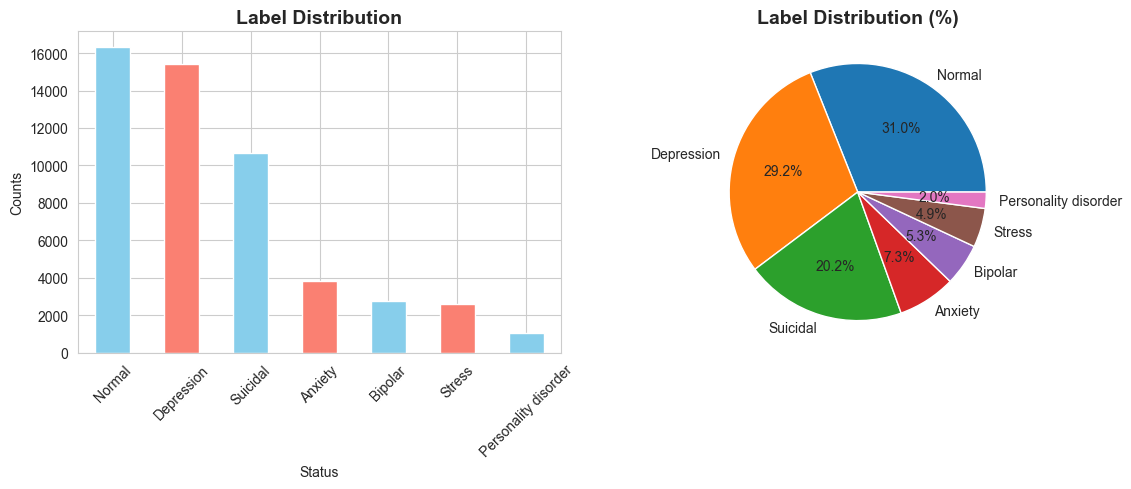

In [11]:
# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
df['status'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Counts')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(df['status'].value_counts().values, labels=df['status'].value_counts().index, autopct='%1.1f%%')
axes[1].set_title('Label Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()


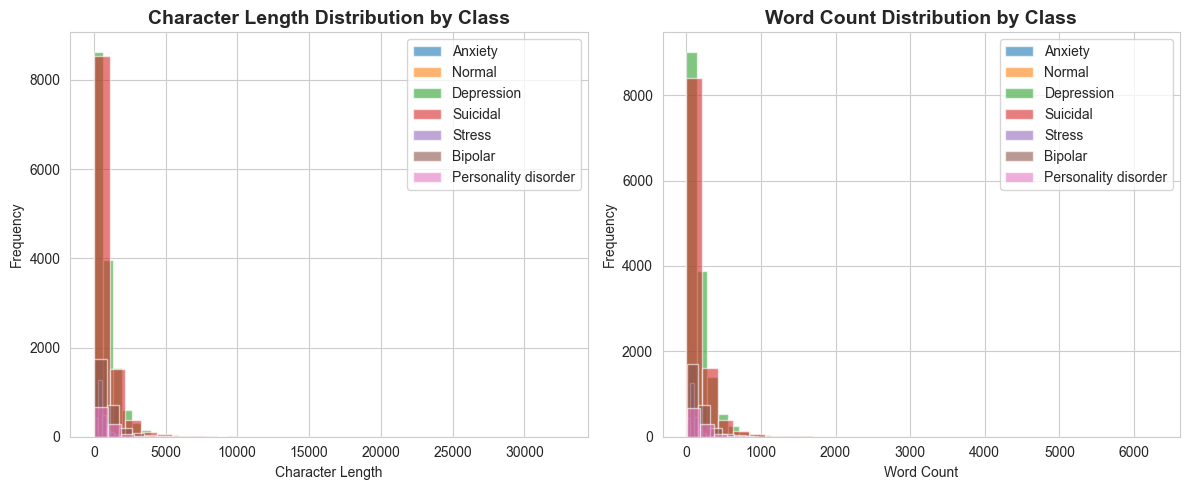

In [12]:
# Text length distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Character length
for label in df['status'].unique():
    subset = df[df['status'] == label]['text_length']
    axes[0].hist(subset, alpha=0.6, label=label, bins=30)
axes[0].set_title('Character Length Distribution by Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Word count
for label in df['status'].unique():
    subset = df[df['status'] == label]['word_count']
    axes[1].hist(subset, alpha=0.6, label=label, bins=30)
axes[1].set_title('Word Count Distribution by Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()

In [13]:
# Sample texts from each class
print('=' * 60)
print('SAMPLE TEXTS FROM EACH CLASS')
print('=' * 60)
for label in df['status'].unique():
    print(f'\n---{label.upper()}---')
    samples = df[df['status'] == label]['statement'].head(1).tolist()
    print(samples)

SAMPLE TEXTS FROM EACH CLASS

---ANXIETY---
['oh my gosh']

---NORMAL---
['Gr gr dreaming of ex crush to be my game, God']

---DEPRESSION---
['I recently went through a breakup and she said she still wants to be friends so I said I can try doing that but when she talks to me about things it always hurts. I just want to lose feelings so all this pain can stop it hurts so much and I cannot even cry about it. I do not want to hurt her because she said she does not want to never speak to me again but I do not know what to do here. When we were together she always hurt me so I do not know why I still love her. I wish we never met it would be much less painful How do I lose feelings?']

---SUICIDAL---
["I am so exhausted of this. Just when I think I can finally rest, just when I think maybe things are starting to settle, another hurdle comes flying at me. This month alone we found out my mum could be dying, my girlfriend left me, my parents revealed that they wanted a divorce, my grandad was

## Data Preprocessing

In [14]:
import re
import string

class TextPreprocessor:

    def __init__(self, max_vocab_size=10000, embedding_dim=100, max_seq_length=100):
        self.max_vocab_size = max_vocab_size
        self.embedding_dim = embedding_dim
        self.max_seq_length = max_seq_length
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.vocab_size = 2
        
    
    def clean_text(self, text):
        text = text.lower()
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        # Remove user mentionis and hashhtags
        text = re.sub(r'\@\w+|\#', '', text)
        # Remove punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        return text


    def build_vocab(self, texts):
        word_counts = Counter()
        for text in texts:
            cleaned_text = self.clean_text(text)
            words = cleaned_text.split()
            word_counts.update(words)

        most_common = word_counts.most_common(self.max_vocab_size - 2)
        for word, frequency in most_common:
            if word not in self.word2idx.keys():
                self.word2idx[word] = self.vocab_size
                self.idx2word[self.vocab_size] = word
                self.vocab_size += 1
        
        print(f"Vocab size: {self.vocab_size}")


    def text_to_sequence(self, text):
        cleaned_text = self.clean_text(text)
        words = cleaned_text.split()
        sequence = [self.word2idx.get(word, self.word2idx['<UNK>']) for word in words]
        if len(sequence) > self.max_seq_length:
            sequence = sequence[:self.max_seq_length]
        
        return sequence
    

    def encode_texts(self, texts):
        return [self.text_to_sequence(text) for text in texts]

In [27]:
preprocessor = TextPreprocessor()
print('=' * 60)
print("PREPROCESSINGI")
print('=' * 60)

# Prepare labels
label_encoder = {label: idx for idx, label in enumerate(df['status'].unique().tolist())}
label_decoder = {idx: label for label, idx in label_encoder.items()}
print(label_encoder)
print(label_decoder)
df['status'] = df['status'].map(label_encoder)
df.head()

PREPROCESSINGI
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6}
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6}


,Unnamed: 0,statement,status,text_length,word_count
0,0,oh my gosh,0,10,3
1,1,"trouble sleeping, confused mind, restless hear...",0,64,10
2,2,"All wrong, back off dear, forward doubt. Stay ...",0,78,14
3,3,I've shifted my focus to something else but I'...,0,61,11
4,4,"I'm restless and restless, it's been a month n...",0,72,14


In [28]:
# Split data
X = df['statement'].values
y = df['status'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f'Train size: {len(X_train)}')
print(f'Validation size: {len(X_val)}')
print(f'Test size: {len(X_test)}')

Train size: 42144
Validation size: 5268
Test size: 5269


In [33]:
# Build vocabulary on training data only
preprocessor.build_vocab(X_train)

# Encode all splits
X_train_encoded = preprocessor.encode_texts(X_train)
X_val_encoded = preprocessor.encode_texts(X_val)
X_test_encoded = preprocessor.encode_texts(X_test)

print(f'Example encoded sequence: {X_train_encoded[0]}')
print(f'Example original text: {X_train[0]}')
print(label_encoder.get(y_train[0]))

Vocab size: 10000
Example encoded sequence: [2, 13, 40, 165, 3, 100, 1125, 305, 4, 60, 756, 153, 86, 243, 44, 17, 2, 295, 38, 2, 15, 159, 8, 27, 270, 9, 546, 931, 21, 137, 240, 321, 108, 5, 436, 352, 16, 33, 7, 776, 77, 3201, 1236, 2, 15, 1354, 4, 118, 82, 83, 23, 676, 2, 29, 25, 2, 944, 6, 2038, 23, 21, 411, 4, 2, 15, 788, 2, 47, 667, 8, 2, 125, 368, 20, 26, 3202, 3, 86]
Example original text: I have been trying to make plans recently and she keeps having things come up but i understand because i am doing it on kind of short notice. This last little bit after the break happened in about a 8 day span. TLDR: I am awkward and need some help with relationships. I feel like i ruined my chances with this girl and i am hoping i can fix it. I also may just be overreacting to things.
1


## Dataset and Dataloader

In [34]:
class TextDataset(Dataset):
    
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels


    def __len__(self):
        return len(self.sequences)


    def __getitem__(self, index):
        return (
            torch.tensor(self.sequences[index], dtype=torch.long),
            torch.tensor(self.labels[index], dtype=torch.long)
        )

In [35]:
def collate_fn(batch):
    """Custom collate function to pad sequences"""
    sequences, labels = zip(*batch)
    sequences_padded = pad_sequence(sequences, batch_first=True, padding_value=0)
    labels = torch.stack(labels)
    return sequences_padded, labels

In [38]:
# Create datasets
train_dataset = TextDataset(X_train_encoded, y_train)
val_dataset = TextDataset(X_val_encoded, y_val)
test_dataset = TextDataset(X_test_encoded, y_test)

# Create dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print(f"\nNumber of batches : Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")



Number of batches : Train: 659, Val: 83, Test: 83


## Model Architectures

In [56]:
class SimpleRNNModel(nn.Module):
    """
    Simple RNN for text classification
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers=1, dropout=0.3):
        super(SimpleRNNModel, self).__init__()
        
        self.embedding = nn.Embedding (
            vocab_size,
            embedding_dim
        )
        self.rnn = nn.RNN (
            embedding_dim,
            hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)


    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.dropout(self.embedding(x))  # (batch_size, seq_len, embedding_dim)
        output, hidden = self.rnn(embedded)  # output: (batch_size, seq_len, hidden_dim)
        
        # Use last hidden state
        hidden = hidden[-1]  # (batch_size, hidden_dim)
        hidden = self.dropout(hidden)
        
        out = self.fc(hidden)  # (batch_size, output_dim)
        return out

In [57]:
class LSTMModel(nn.Module):
    """LSTM for text classification"""
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, 
                 n_layers=1, dropout=0.3):
        super(LSTMModel, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.dropout(self.embedding(x))  # (batch_size, seq_len, embedding_dim)
        output, (hidden, cell) = self.lstm(embedded)  # output: (batch_size, seq_len, hidden_dim)
        
        # Use last hidden state
        hidden = hidden[-1]  # (batch_size, hidden_dim)
        hidden = self.dropout(hidden)
        
        out = self.fc(hidden)  # (batch_size, output_dim)
        return out

In [74]:
class BiLSTMModel(nn.Module):
    """Bidirectional LSTM model for text classification."""
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, dropout=0.3):
        super(BiLSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, num_layers=1, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        # Note: hidden_dim * 2 because bidirectional concatenates forward and backward hidden states
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    
    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        output, (hidden, cell) = self.lstm(embedded)  
        # hidden: (num_layers * num_directions, batch_size, hidden_dim)
        # For bidirectional: hidden[-2] is forward, hidden[-1] is backward
        # Concatenate the final forward and backward hidden states
        hidden_concat = torch.cat((hidden[-2], hidden[-1]), dim=1)  # (batch_size, hidden_dim * 2)
        dropped = self.dropout(hidden_concat)
        logits = self.fc(dropped)  # (batch_size, num_classes)
        return logits


In [75]:
# Model configuration
VOCAB_SIZE = preprocessor.vocab_size
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
OUTPUT_DIM = len(label_encoder)
N_LAYERS = 2
DROPOUT = 0.3

# Initialize models
rnn_model = SimpleRNNModel(
    VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT
).to(device)

lstm_model = LSTMModel(
    VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT
).to(device)

bilstm_model = BiLSTMModel(
    VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, DROPOUT
).to(device)

# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("MODEL ARCHITECTURES")
print("=" * 60)
print(f"\n📊 Simple RNN Parameters: {count_parameters(rnn_model):,}")
print(f"📊 LSTM Parameters: {count_parameters(lstm_model):,}")

print(f"\n🔹 Simple RNN Architecture:")
print(rnn_model)

print(f"\n🔹 LSTM Architecture:")
print(lstm_model)

print(f"\n🔹 Bidirectional LSTM Architecture:")
bilstm_params = count_parameters(bilstm_model)
print(bilstm_model)
print(f"  Bidirectional LSTM: {bilstm_params:,}")



MODEL ARCHITECTURES

📊 Simple RNN Parameters: 1,512,199
📊 LSTM Parameters: 2,203,399

🔹 Simple RNN Architecture:
SimpleRNNModel(
  (embedding): Embedding(10000, 128)
  (rnn): RNN(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=7, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

🔹 LSTM Architecture:
LSTMModel(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=7, bias=True)
)

🔹 Bidirectional LSTM Architecture:
BiLSTMModel(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 256, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=7, bias=True)
)
  Bidirectional LSTM: 2,074,119


## Train

In [59]:
class Trainer:
    """
    Handles training and evaluation
    """

    def __init__(self, model, model_name, device):
        self.model = model
        self.model_name = model_name
        self.device = device
        self.history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'train_time': [],
        }

    def train_epoch(self, dataloader, criterion, optimizer):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0
        for sequences, labels in dataloader:
            sequences = sequences.to(self.device)
            labels = labels.to(self.device)

            # Forward pass
            optimizer.zero_grad()
            outputs = self.model(sequences)
            loss = criterion(outputs, labels)

            # Bacward pass
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=5)

            optimizer.step()

            # Calculate accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(dataloader)
        accuracy = correct / total * 100
        return avg_loss, accuracy
    

    def evaluate(self, dataloader, criterion):
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for sequences, labels in dataloader:
                sequences = sequences.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(sequences)
                loss = criterion(outputs, labels)

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                total_loss += loss.item()
        avg_loss = total_loss / len(dataloader)
        accuracy = correct / total * 100
        return avg_loss, accuracy
    
    def train(self, train_loader, val_loader, epochs, learning_rate):
        """Full training loop"""
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)

        print(f'=' * 60)
        print(f'Training {self.model_name}')
        print(f'=' * 60)

        for epoch in range(epochs):
            start_time = time.time()

            # Train
            train_loss, train_acc = self.train_epoch(
                train_loader, criterion, optimizer
            )

            # Validate
            val_loss, val_acc = self.evaluate(
                val_loader, criterion
            )

            epoch_time = time.time() - start_time

            # Store history
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['train_time'].append(epoch_time)

            # Print progress
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
                  f"Time: {epoch_time:.2f}s")
        
        print(f"\n✅ Training completed for {self.model_name}")
        return self.history



## Train Both Models

In [79]:
EPOCHS = 20
LEARNING_RATE = 0.001

# Train Simple RNN
rnn_trainer = Trainer(rnn_model, 'Simple RNN', device)
rnn_history = rnn_trainer.train(train_loader, val_loader, EPOCHS, LEARNING_RATE)

# Train LSTM
lstm_trainer = Trainer(lstm_model, 'LSTM', device)
lstm_history = lstm_trainer.train(train_loader, val_loader, EPOCHS, LEARNING_RATE)  

# Train Bidirectional LSTM
bilstm_trainer = Trainer(bilstm_model, "Bidirectional LSTM", device)
bilstm_history = bilstm_trainer.train(train_loader, val_loader, EPOCHS, LEARNING_RATE)


Training Simple RNN
Epoch 1/20 | Train Loss: 1.5071 | Train Acc: 45.30% | Val Loss: 1.4547 | Val Acc: 47.00% | Time: 26.37s
Epoch 2/20 | Train Loss: 1.4976 | Train Acc: 45.15% | Val Loss: 1.4612 | Val Acc: 47.10% | Time: 26.15s
Epoch 3/20 | Train Loss: 1.5096 | Train Acc: 44.84% | Val Loss: 1.4674 | Val Acc: 47.00% | Time: 26.10s
Epoch 4/20 | Train Loss: 1.4888 | Train Acc: 45.55% | Val Loss: 1.4522 | Val Acc: 47.17% | Time: 26.38s
Epoch 5/20 | Train Loss: 1.4902 | Train Acc: 45.20% | Val Loss: 1.4661 | Val Acc: 46.87% | Time: 26.58s
Epoch 6/20 | Train Loss: 1.4701 | Train Acc: 45.38% | Val Loss: 1.4369 | Val Acc: 47.19% | Time: 28.35s
Epoch 7/20 | Train Loss: 1.4638 | Train Acc: 45.51% | Val Loss: 1.4209 | Val Acc: 46.92% | Time: 28.62s
Epoch 8/20 | Train Loss: 1.4522 | Train Acc: 45.69% | Val Loss: 1.3971 | Val Acc: 47.48% | Time: 28.35s
Epoch 9/20 | Train Loss: 1.4669 | Train Acc: 45.38% | Val Loss: 1.4388 | Val Acc: 47.15% | Time: 28.42s
Epoch 10/20 | Train Loss: 1.4831 | Train Acc

## Plot

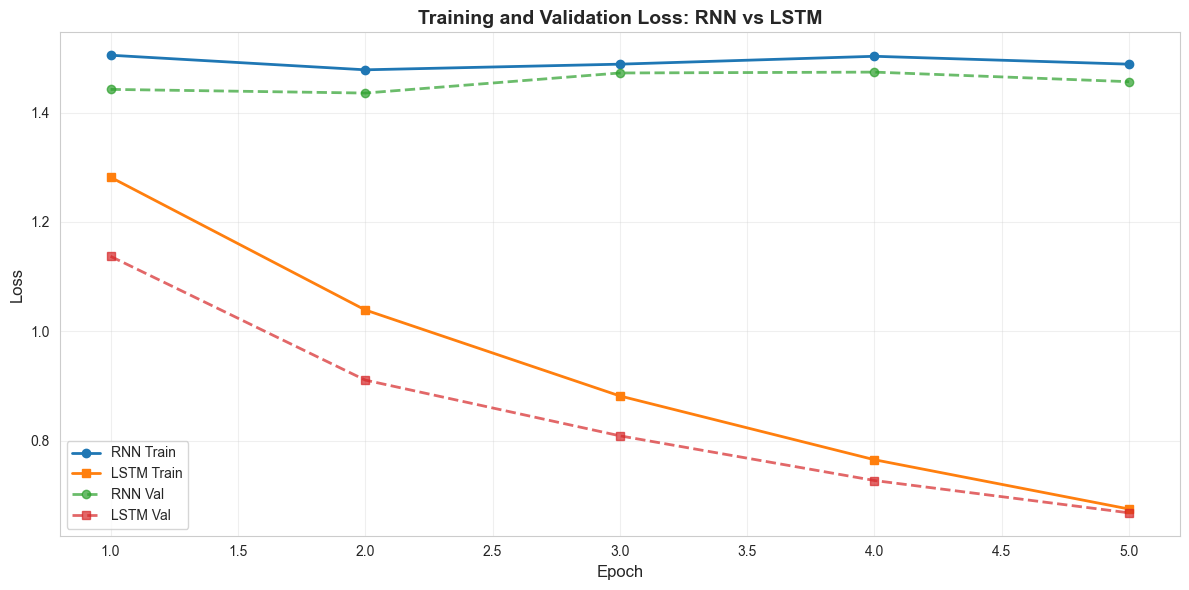

In [61]:
# Plot 1: Training Loss Comparison
fig, ax = plt.subplots(figsize=(12, 6))
epochs_range = range(1, EPOCHS + 1)

ax.plot(epochs_range, rnn_history['train_loss'], 'o-', label='RNN Train', linewidth=2)
ax.plot(epochs_range, lstm_history['train_loss'], 's-', label='LSTM Train', linewidth=2)
ax.plot(epochs_range, rnn_history['val_loss'], 'o--', label='RNN Val', linewidth=2, alpha=0.7)
ax.plot(epochs_range, lstm_history['val_loss'], 's--', label='LSTM Val', linewidth=2, alpha=0.7)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training and Validation Loss: RNN vs LSTM', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_loss_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


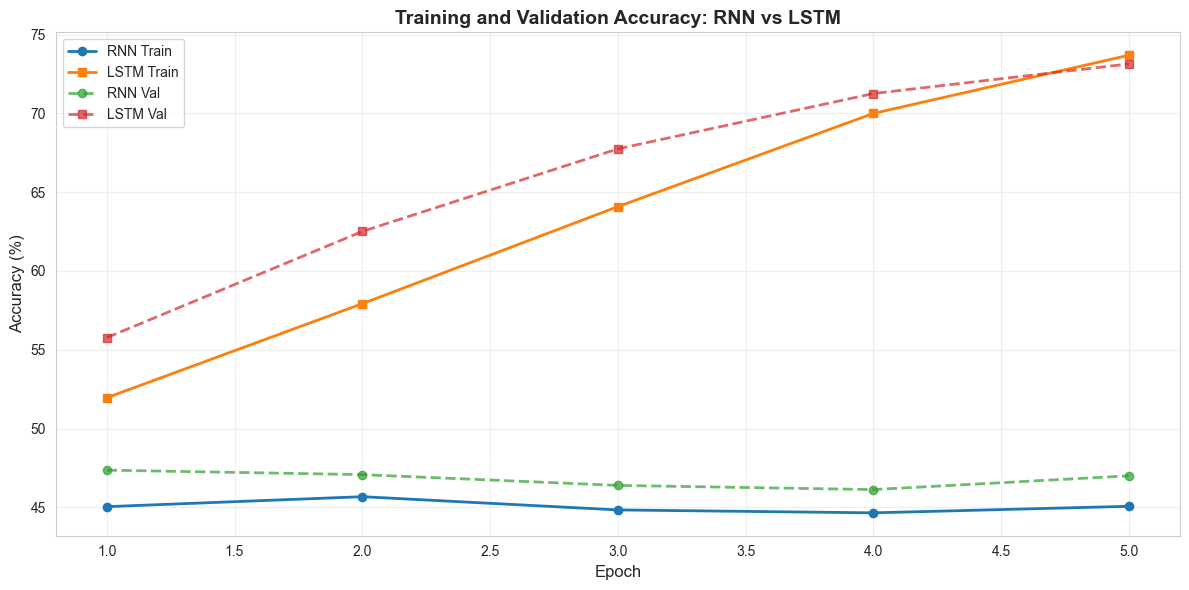

In [62]:
# Plot 2: Accuracy Comparison
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(epochs_range, rnn_history['train_acc'], 'o-', label='RNN Train', linewidth=2)
ax.plot(epochs_range, lstm_history['train_acc'], 's-', label='LSTM Train', linewidth=2)
ax.plot(epochs_range, rnn_history['val_acc'], 'o--', label='RNN Val', linewidth=2, alpha=0.7)
ax.plot(epochs_range, lstm_history['val_acc'], 's--', label='LSTM Val', linewidth=2, alpha=0.7)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Training and Validation Accuracy: RNN vs LSTM', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

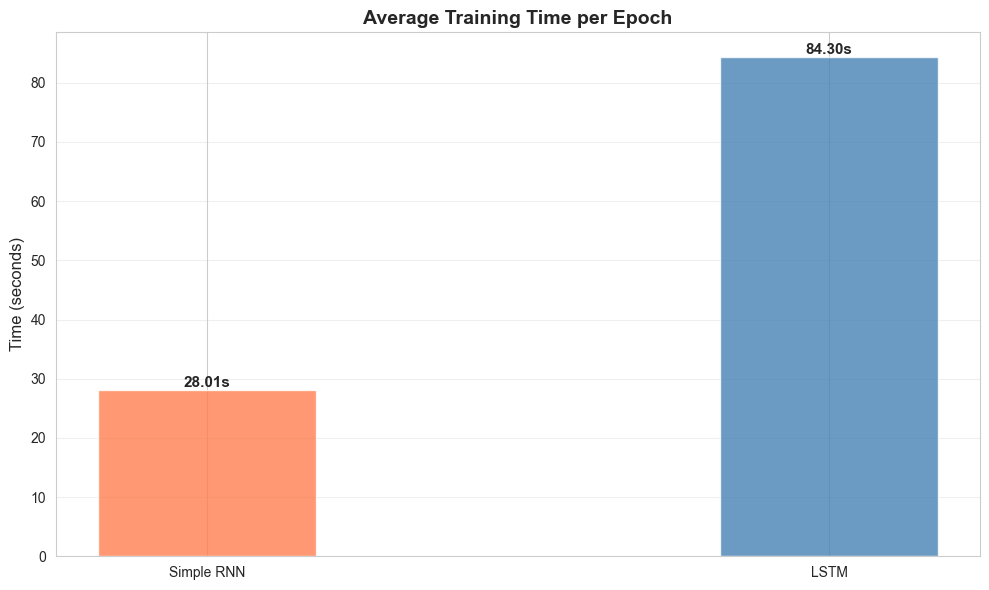


⏱️ RNN average time per epoch: 28.01s
⏱️ LSTM average time per epoch: 84.30s
⏱️ LSTM is 200.9% slower (expected due to more gates)


In [64]:
# Plot 4: Training Time per Epoch
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(2)
width = 0.35

rnn_avg_time = np.mean(rnn_history['train_time'])
lstm_avg_time = np.mean(lstm_history['train_time'])

bars = ax.bar(x, [rnn_avg_time, lstm_avg_time], width, 
              color=['coral', 'steelblue'], alpha=0.8)

ax.set_ylabel('Time (seconds)', fontsize=12)
ax.set_title('Average Training Time per Epoch', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Simple RNN', 'LSTM'])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}s',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('06_training_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n⏱️ RNN average time per epoch: {rnn_avg_time:.2f}s")
print(f"⏱️ LSTM average time per epoch: {lstm_avg_time:.2f}s")
print(f"⏱️ LSTM is {(lstm_avg_time/rnn_avg_time - 1)*100:.1f}% slower (expected due to more gates)")


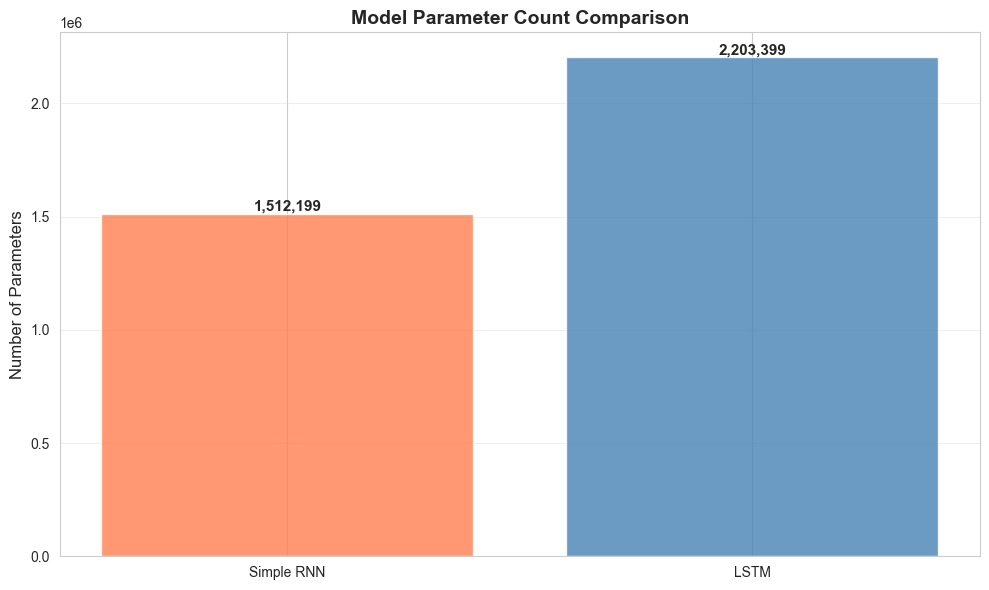


🔢 RNN parameters: 1,512,199
🔢 LSTM parameters: 2,203,399
🔢 LSTM has 45.7% more parameters (4x gates)


In [65]:
# Plot 5: Parameter Count Comparison
fig, ax = plt.subplots(figsize=(10, 6))

rnn_params = count_parameters(rnn_model)
lstm_params = count_parameters(lstm_model)

bars = ax.bar(['Simple RNN', 'LSTM'], [rnn_params, lstm_params], 
              color=['coral', 'steelblue'], alpha=0.8)

ax.set_ylabel('Number of Parameters', fontsize=12)
ax.set_title('Model Parameter Count Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('07_parameter_count_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🔢 RNN parameters: {rnn_params:,}")
print(f"🔢 LSTM parameters: {lstm_params:,}")
print(f"🔢 LSTM has {(lstm_params/rnn_params - 1)*100:.1f}% more parameters (4x gates)")


## Test Set Evaluation

In [72]:
def detailed_evaluation(model, dataloader, model_name, label_decoder):
    """Comprehensive evaluation with metrics"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for sequences, labels in dataloader:
            sequences = sequences.to(device)
            labels = labels.to(device)
            
            outputs = model(sequences)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    print(f"\n{'=' * 60}")
    print(f"{model_name} - Test Set Evaluation")
    print(f"{'=' * 60}")
    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    # Classification report
    print(f"\n📊 Classification Report:")
    target_names = [label_decoder[i] for i in sorted(label_decoder.keys())]
    # print(classification_report(all_labels, all_preds, target_names=target_names))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'predictions': all_preds,
        'labels': all_labels
    }

In [73]:
# Evaluate both models
rnn_results = detailed_evaluation(rnn_model, test_loader, "Simple RNN", label_decoder)
lstm_results = detailed_evaluation(lstm_model, test_loader, "LSTM", label_decoder)



Simple RNN - Test Set Evaluation
Accuracy:  46.67%
Precision: 0.3782
Recall:    0.4667
F1-Score:  0.3602

📊 Classification Report:

LSTM - Test Set Evaluation
Accuracy:  74.07%
Precision: 0.7355
Recall:    0.7407
F1-Score:  0.7362

📊 Classification Report:
